In [1]:
import osmnx as ox
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import matplotlib.colors as mcolors
import pickle
import contextily as ctx
import subprocess
import xml.etree.ElementTree as ET
import numpy as np

print(ox.__version__)

#in the settings specify a single date

2.0.1


# Define Scenario Configs

In [2]:
studyArea = 'sfbay'

simpl_intersections = 2
splitLinksBy = ["highway","lanes", "maxspeed", "hgv", "mgv"]
#Define custom filters
cf1 = '["highway"~"motorway|primary|trunk|secondary|tertiary|motorway_link|trunk_link|primary_link|secondary_link|tertiary_link|unclassified"]'
cf2 = '["highway"~"residential"]'
cf3 = '["highway"~"motorway|primary|residential|trunk|secondary|tertiary|motorway_link|trunk_link|primary_link|secondary_link|tertiary_link|unclassified"]'

desired_tags = ["maxweight", "hgv", "maxweight:hgv", "maxlength", "maxaxleload"]
ox.settings.useful_tags_way = list(ox.settings.useful_tags_way) + desired_tags

# Filter access = private ... look at edge and nodes attirbtues for more

if studyArea == 'sfbay':
    is_addresses = False
    is_bboxes = False
    is_places = True
    is_points = False
    is_polygons = False
    is_xmls = False
    ########  PLACE  ##############################

    # Input places (list of place names)
    places = [
        {"county": "San Francisco", "state": "California"},
        {"county": "San Francisco", "state": "California"},
        {"county": "Alameda", "state": "California"},
        {"county": "Contra Costa", "state": "California"},
        {"county": "Marin", "state": "California"},
        {"county": "Napa", "state": "California"},
        {"county": "San Mateo", "state": "California"},
        {"county": "Santa Clara", "state": "California"},
        {"county": "Solano", "state": "California"},
        {"county": "Sonoma", "state": "California"},
    ]


    places_filters = {
        "network_type": "drive", 
        "simplify": False,          
        "retain_all": True,              
        "truncate_by_edge": True,
        "which_result": None,  
        "custom_filter": [
            cf3,cf1,cf1,cf1,cf1,cf1,cf1,cf1,cf1
             ]}
    

else:

    is_addresses = False
    is_bboxes = False
    is_places = True
    is_points = False
    is_polygons = False
    is_xmls = False

    studyArea = 'NewYork'


    # 0.00008983 = 10m
    simpl_intersections = 2
    splitLinksBy = ["highway","lanes", "maxspeed"]

    #Define custom filters
    cf1 = '["highway"~"motorway|primary|trunk|secondary|tertiary|motorway_link|trunk_link|primary_link|secondary_link|tertiary_link|unclassified"]'
    cf3 = '["highway"~"residential|motorway|primary|trunk|secondary|tertiary|motorway_link|trunk_link|primary_link|secondary_link|tertiary_link|unclassified"]'
    cf2 = '["highway"~"residential"]'
    cf_main_highways = '["highway"="motorway"]'

    ##############################  ADDRESS  ##############################
    addresses = ["San Francisco, CA, USA", "San Francisco, CA, USA"]
    # addresses = ["Milano, IT", "Milano, IT"]
    addresses_filters = {
        "dist": 5000,  
        "dist_type": 'bbox',  # "network", "bbox" if “bbox”, retain only those nodes within a 
                              # bounding box of the distance parameter. if “network”, retain 
                              # only those nodes within some network distance from the center-most node.
        "network_type": "drive",  #all", "all_public", "bike", "drive", "drive_service", "walk"
        "simplify": False,     
        "retain_all": True,   # if True, return the entire graph even if it is not connected. otherwise, 
                              # retain only the largest weakly connected component.
        "truncate_by_edge": None, # if True, retain nodes outside bounding box if at least one 
                                          # of node’s neighbors is within the bounding box
        "custom_filter": [cf2, cf1]  #'["highway"~"motorway|trunk"]' ‘[“power”~”line”]’ or ‘[“highway”~”motorway|trunk”]’.
    }

    ##############################  BBOX  ##############################

    #Input bounding boxes (list of tuples representing bounding box coordinates)
    bboxes = [(37.8, 37.7, -122.5, -122.4), (37.9, 37.8, -122.3, -122.2)]
    bboxes_filters = {
        "network_typeTrue": ["drive", "bike"], 
        "simplify": [False, False],          
        "retain_all": True,                 
        "truncate_by_edge": [True, True],  
        "custom_filter": [cf2, cf1] 
    }

    ##############################  PLACE  ##############################

    # Input places (list of place names)
    places = [
        {"county": "San Francisco", "state": "California"},
        {"county": "San Francisco", "state": "California"},
        {"county": "Alameda", "state": "California"},
        {"county": "Contra Costa", "state": "California"},
        {"county": "Marin", "state": "California"},
        {"county": "Napa", "state": "California"},
        {"county": "San Mateo", "state": "California"},
        {"county": "Santa Clara", "state": "California"},
        {"county": "Solano", "state": "California"},
        {"county": "Sonoma", "state": "California"},]


    places_filters = {
        "network_type": "drive",
        "simplify": False,          
        "retain_all": True,                 
        "truncate_by_edge": False, 
        "which_result": None,    
        "custom_filter": [
            cf3,cf1,cf1,cf1,cf1,cf1,cf1,cf1,cf1,cf1
             ]}

    ##############################  POINT  ##############################

    # Input points (list of tuples, each containing (latitude, longitude))
    points = [(37.556036, -122.268709)]

    # San Francisco and Oakland
    points_filters = {
        "dist": [1000],                # Retain only those nodes within this many meters of the center of the graph
        "dist_type": 'bbox',          
        "network_type": ["drive", "bike"], 
        "simplify": [False, False],          
        "retain_all": True,                 
        "truncate_by_edge": [False, True], 
        "custom_filter": cf1
    }

    # Input polygons (using geocode to get polygon boundaries)
    # (shapely.geometry.Polygon or shapely.geometry.MultiPolygon) – the shape to get network data within. 
    # coordinates should be in unprojected latitude-longitude degrees (EPSG:4326).

    ##############################  POLYGON  ##############################


    # polygons = [ox.geocode_to_gdf("Downtown San Francisco"), ox.geocode_to_gdf("Oakland")]
    polygons_filters = {
        "network_type": ["drive", "bike"], 
        "simplify": [False, False],          
        "retain_all": True,                 
        "truncate_by_edge": [True, True], 
        "custom_filter": '["building"~"yes"]' 
    }

    # Input XML files (paths to files that contain OSM data in XML format)
    xmls = ["/path/to/sf.osm", "/path/to/berkeley.osm"]
    xmls_filters = {
        "bidirectional": False, ####
        "simplify": [False, False],          
        "retain_all": True,   
        "encoding": "utf-8", ####                
        "custom_filter": '["highway"~"residential"]'  
    }

# INPUTS

In [3]:
# Generate the graph in 6 different ways
# Turn on the methods to be used, and insert the inputs
# Use lists to combine multiple graphs, and single values for common filter parameters



# FUNCTIONS

In [4]:


# Helper function to get the appropriate value from the filter
def get_filter_value(filter_param, index, total_count):
    if isinstance(filter_param, list):
        # If the parameter is a list, return the value for the current index
        return filter_param[index % len(filter_param)]
    else:
        # If the parameter is a single value, return the same value for all
        return filter_param

# Helper function to apply filters dynamically
def apply_filters(filters, index, total_count):
    return {key: get_filter_value(value, index, total_count) for key, value in filters.items()}

# Generic function to generate graphs based on a method and a list of inputs
def generate_graphs(inputs, filters, graph_function):
    graphs = []
    for i, input_data in enumerate(inputs):
        # Dynamically apply filters based on index
        print(input_data)
        dynamic_filters = apply_filters(filters, i, len(inputs))
        print(dynamic_filters)
        graph = graph_function(input_data, **dynamic_filters)
#         plot(graph, f'{input_data}_{str(simpl_intersections)}_original_graph')
        graphs.append(graph)
    return nx.compose_all(graphs) if graphs else None

# Specific functions using the generate_graphs utility

def get_graph_from_address(addresses, filters):
    return generate_graphs(addresses, filters, ox.graph_from_address)

def get_graph_from_bbox(bboxes, filters):
    return generate_graphs(bboxes, filters, lambda bbox, **kwargs: ox.graph_from_bbox(*bbox, **kwargs))

def get_graph_from_place(places, filters):
    return generate_graphs(places, filters, ox.graph_from_place)

def get_graph_from_point(points, filters):
    return generate_graphs(points, filters, ox.graph_from_point)

def get_graph_from_polygon(polygons, filters):
    return generate_graphs(polygons, filters, lambda polygon, **kwargs: ox.graph_from_polygon(polygon.geometry[0], **kwargs))

def get_graph_from_xml(xmls, filters):
    return generate_graphs(xmls, filters, ox.graph_from_xml)


# Function to generate and combine graphs
def combine_graphs():
    combined_graphs = []

    if is_addresses:
        address_graph = get_graph_from_address(addresses, addresses_filters)
        if address_graph is not None:
            combined_graphs.append(address_graph)
    
    if is_bboxes:
        bbox_graph = get_graph_from_bbox(bboxes, bboxes_filters)
        if bbox_graph is not None:
            combined_graphs.append(bbox_graph)
    
    if is_places:
        place_graph = get_graph_from_place(places, places_filters)
        if place_graph is not None:
            combined_graphs.append(place_graph)
    
    if is_points:
        point_graph = get_graph_from_point(points, points_filters)
        if point_graph is not None:
            combined_graphs.append(point_graph)
    
    if is_polygons:
        polygon_graph = get_graph_from_polygon(polygons, polygons_filters)
        if polygon_graph is not None:
            combined_graphs.append(polygon_graph)
    
    if is_xmls:
        xml_graph = get_graph_from_xml(xmls, xmls_filters)
        if xml_graph is not None:
            combined_graphs.append(xml_graph)

    # Return the combined graph if there are any valid graphs, else return None
    return nx.compose_all(combined_graphs) if combined_graphs else None

def plot(G, name):
    fig, ax = ox.plot.plot_graph(
        G,
        bgcolor="#FFFFFF",         # Light background
#         node_color="#00FFAA",      # Bright teal nodes
        node_color="#333333",      # Bright teal nodes
        node_size=0.02,
        node_edgecolor='none',     # Node size  2.5
#         node_alpha=0.8,            # Node transparency
#         node_edgecolor="#333333",  # Dark edges around nodes
        node_zorder=3,             # Nodes above edges
        edge_color="#FF5A5F",      # Bright coral edges
        edge_linewidth=0.2,          # Edge thickness 0.5
        edge_alpha=0.8,            # Edge transparency
        show=False,                # Do not display immediately
        close=False                # Keep the plot open for saving
    )
    
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    # 3. Calculate statistics
    num_nodes = len(G.nodes)
    num_edges = len(G.edges)
    # Total length in meters
    total_length = sum(data.get('length', 0) for u, v, key, data in G.edges(keys=True, data=True))

    # 4. Add title with statistics
    title = (
        f"Nodes: {num_nodes} | Edges: {num_edges} | Total Length: {total_length/1000:.2f} km"
    )
    ax.set_title(title, fontsize=15, fontweight='bold', color='black', pad=20)
    

    # 5. Save the figure with 600 DPI
    fig.savefig(f'{name}.png', dpi=600, bbox_inches='tight')
    
# Helper function to plot graph by attribute with legend
def plot_graph_by_attribute(G, attribute, title, figsize=(12, 12)):
    # Extract values of the specified attribute from the edges
    attribute_values = [G.edges[edge].get(attribute, 'unknown') for edge in G.edges]

    # Determine if the attribute is categorical or numerical
    if isinstance(attribute_values[0], str) or isinstance(attribute_values[0], bool):  # Categorical
        unique_values = list(set(attribute_values))
        colors = plt.cm.get_cmap('tab20', len(unique_values))(range(len(unique_values)))
        colors = colors[np.random.permutation(len(unique_values))]
        color_map = dict(zip(unique_values, colors))
        edge_colors = [color_map[val] for val in attribute_values]
    else:  # Numerical
        norm = mcolors.Normalize(vmin=min(attribute_values), vmax=max(attribute_values))
        color_map = plt.cm.ScalarMappable(norm=norm, cmap='plasma')
        edge_colors = [color_map.to_rgba(val) for val in attribute_values]

    # Plot the graph with edges colored by the specified attribute
    fig, ax = plt.subplots(figsize=figsize)
    ox.plot_graph(
        G,
        ax=ax,
        bgcolor="#222222",
        node_color="#00FFAA",
        node_size=0.2,
        node_alpha=0.9,
        node_edgecolor="#333333",
        edge_color=edge_colors,
        edge_linewidth=0.7,
        edge_alpha=1,
        show=False,
        close=False
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    # Set title
    ax.set_title(title, color="white")

    # Add legend for categorical attributes
    if isinstance(attribute_values[0], str) or isinstance(attribute_values[0], bool):
        handles = [plt.Line2D([0], [0], color=color_map[val], lw=4) for val in unique_values]
        ax.legend(handles, unique_values, title=attribute, loc="lower right", frameon=False, fontsize=10)
    elif isinstance(attribute_values[0], (int, float)):
        # Add a color bar for numerical attributes
        cbar = plt.colorbar(color_map, ax=ax)
        cbar.set_label(attribute)

    fig.savefig(f'{studyArea}_{attribute}.png', dpi=600, bbox_inches='tight')
    plt.show()
    
def analyze_specific_edge_attributes(df):
    # Descriptive stats for numeric attributes
    numeric_summary = df[['length', 'speed_kph']].describe().T.round(2)
    print("\nDescriptive statistics for numeric attributes in edges:")
    display(numeric_summary)
    
    # Value counts for each categorical attribute in edges
    categorical_attributes = ['oneway', 'maxspeed', 'lanes', 'sidewalk', 'cycleway', 
                              'access', 'maxweight', 'hgv', 'highway']
    for attr in categorical_attributes:
        print(f"\nValue counts for '{attr}' in edges:")
        value_counts_df = df[attr].value_counts(dropna=False).to_frame(name="Count")
        display(value_counts_df)

def analyze_specific_node_attributes(df):
    # Value counts for each categorical attribute in nodes
    node_categorical_attributes = ['street_count', 'traffic_signals']
    for attr in node_categorical_attributes:
        print(f"\nValue counts for '{attr}' in nodes:")
        value_counts_df = df[attr].value_counts(dropna=False).to_frame(name="Count")
        display(value_counts_df)

def save_graph_to_osm(G, filename="output.osm"):
    # Bounding box
    xs = [d['x'] for _, d in G.nodes(data=True) if 'x' in d]
    ys = [d['y'] for _, d in G.nodes(data=True) if 'y' in d]
    minlon, maxlon = min(xs), max(xs)
    minlat, maxlat = min(ys), max(ys)

    root = ET.Element("osm", version="0.6", generator="OSMnx2OSM")
    ET.SubElement(root, "bounds",
        minlat=str(minlat), minlon=str(minlon),
        maxlat=str(maxlat), maxlon=str(maxlon))

    node_map = {}
    node_id = 1

    # Write nodes + attributes as tags
    for n, d in G.nodes(data=True):
        lat, lon = d.get('y'), d.get('x')
        if lat is None or lon is None: continue
        node = ET.SubElement(root, "node",
            id=str(node_id), lat=str(lat), lon=str(lon),
            version="1", changeset="1", user="osmnx", uid="1",
            timestamp="2020-01-01T00:00:00Z"
        )
        node_map[n] = node_id
        for k, v in d.items():
            if k not in ("x", "y") and v is not None:
                ET.SubElement(node, "tag", k=str(k), v=str(v))
        node_id += 1

    # Write ways (edges) + attributes as tags
    way_id = -1
    for u, v, edata in G.edges(data=True):
        if u not in node_map or v not in node_map: 
            continue
        way = ET.SubElement(root, "way",
            id=str(way_id), version="1", changeset="1",
            user="osmnx", uid="1", timestamp="2020-01-01T00:00:00Z")
        ET.SubElement(way, "nd", ref=str(node_map[u]))
        ET.SubElement(way, "nd", ref=str(node_map[v]))
        # At least one standard OSM tag
        ET.SubElement(way, "tag", k="highway", v="road")
        # Dump all other attributes
        for k, v_ in edata.items():
            if v_ is not None:
                ET.SubElement(way, "tag", k=str(k), v=str(v_))
        way_id -= 1

    ET.ElementTree(root).write(filename, encoding="utf-8", xml_declaration=True)

# FUNCTIONS FOR FREIGHT ATTRIBUTES

In [5]:
import re
import pandas as pd

# Example thresholds (adjust as needed)
MDV_LIMIT_LBS = 26000
HDV_LIMIT_LBS = 80000
MDV_LIMIT_FT  = 40
HDV_LIMIT_FT  = 53

def parse_weight_to_lbs(w):
    if not isinstance(w, str):
        return None
    s = w.strip().lower()
    m = re.match(r"(\d+(\.\d+)?)", s)
    if not m:
        return None
    val = float(m.group(1))
    # Simple pattern checks:
    if ' lbs' in s: return val
    if ' st' in s or 'st' in s: return val * 2000  # short tons
    if ' t' in s: return val * 2204.6226          # metric tons
    return val * 2000                             # default to short tons

def parse_length_to_feet(l):
    if not isinstance(l, str):
        return None
    s = l.strip().lower()
    m = re.match(r"(\d+)(\'\d+\"|\'\d+|\'|\")?", s)
    if m:
        return float(m.group(1))
    try:
        return float(s)
    except:
        return None

def parse_hgv(h):
    if h is True:
        return True
    if h is False:
        return False
    if isinstance(h, list) and True in h:
        return True
    return None

def classify_truck_allowed(row):
    w = row.get('maxweight_combined_lbs')
    ft = row.get('maxlength_ft')
    
    # Helper to classify a numeric value (could be weight or length)
    def classify_val(val, md_limit, hd_limit):
        if val >= hd_limit:
            return "HD"
        elif val >= md_limit:
            return "MD"
        else:
            return "LD"
    
    # Classify length if available
    if pd.notnull(ft):
        l_class = classify_val(ft, MDV_LIMIT_FT, HDV_LIMIT_FT)
    else:
        l_class = None
        
    # Classify weight if available
    if pd.notnull(w):
        w_class = classify_val(w, MDV_LIMIT_LBS, HDV_LIMIT_LBS)
    else:
        w_class = None
    
    # Combine logic
    # Priority: if both exist, take the "stricter" (lower) class. 
    # If only one exists, use that. If neither, return None.
    if w_class and l_class:
        rank = {"LD": 0, "MD": 1, "HD": 2}
        return w_class if rank[w_class] <= rank[l_class] else l_class
    elif w_class:
        return w_class
    elif l_class:
        return l_class
    else:
        return None
    
def interpret_hgv_str(val):
    """
    Example logic:
    - "no" remains "no"
    - everything else, treat as "yes"
    
    designated           4613
    no                    424
    destination            34
    delivery               12
    discouraged             6
    yes                     6
    [yes, designated]       3
    Name: hgv, dtype: int64
    """
    if val is None:
        return None
    
    # Flatten list values like [yes, designated], turning them into a single string
    if isinstance(val, list):
        val = " ".join(str(x) for x in val)
    
    # Basic logic: if the string includes 'no', treat it as 'no'; otherwise 'yes'
    val_str = str(val).lower()
    if "no" in val_str:
        return "no"
    return "yes"

def compute_vehicle_allowed(row):
    # Combines the original hgv flag and truck classification.
    orig_hgv = interpret_hgv_str(row['old_hgv'])
    truck_class = row['truck_allowed']
    hgv_allowed = "no" if orig_hgv == "no" or truck_class in ["LD", "MD"] else "yes"
    mgv_allowed = "no" if truck_class in ["LD"] else "yes"
    return pd.Series({"hgv": hgv_allowed, "mgv": mgv_allowed})

def compute_vehicle_allowed_from_truck(row):
    # Bases allowed status solely on truck classification.
    truck_class = row['truck_allowed']
    hgv_allowed = "no" if truck_class in ["LD", "MD"] else "yes"
    mgv_allowed = "no" if truck_class in ["LD"] else "yes"
    return pd.Series({"hgv": hgv_allowed, "mgv": mgv_allowed})

def update_freight_script(edges):
    
    print("Parsing columns if present...")
    for col in ['maxweight:hgv', 'maxweight', 'hgv', 'maxlength']:
        if col in edges.columns:
            print(f"  -> Found '{col}'; parsing...")
            if col in ['maxweight:hgv', 'maxweight']:
                edges[col + '_lbs'] = edges[col].apply(parse_weight_to_lbs)
                edges[col + '_str'] = edges[col + '_lbs'].apply(lambda x: f"{x:,.0f} lbs" if pd.notnull(x) else None)
            elif col == 'hgv':
                edges[col + '_bool'] = edges[col].apply(parse_hgv)
            elif col == 'maxlength':
                edges[col + '_ft'] = edges[col].apply(parse_length_to_feet)
        else:
            print(f"  -> '{col}' not found; skipping.")

    print("Merging 'maxweight:hgv' over 'maxweight' if both exist...")
    if 'maxweight:hgv_lbs' not in edges.columns:
        edges['maxweight:hgv_lbs'] = None
    if 'maxweight_lbs' not in edges.columns:
        edges['maxweight_lbs'] = None

    # Override: if 'maxweight:hgv_lbs' is not null, use it; otherwise use 'maxweight_lbs'
    edges['maxweight_combined_lbs'] = edges.apply(
        lambda x: x['maxweight:hgv_lbs'] if pd.notnull(x['maxweight:hgv_lbs']) else x['maxweight_lbs'],
        axis=1
    )
    edges['maxweight_combined_str'] = edges['maxweight_combined_lbs'].apply(
        lambda w: f"{w:,.0f} lbs" if pd.notnull(w) else None
    )

    print("Classifying truck access based on weight & length thresholds...")
    edges['truck_allowed'] = edges.apply(classify_truck_allowed, axis=1)
    
    
    if 'hgv' in edges.columns:
        # Save the original HGV data.
        edges['old_hgv'] = edges['hgv']
        # Compute new hgv/mgv columns combining old_hgv and truck_allowed.
        edges[['hgv', 'mgv']] = edges.apply(compute_vehicle_allowed, axis=1)
    else:
        # If no original hgv column exists, compute new columns solely from truck_allowed.
        edges[['hgv', 'mgv']] = edges.apply(compute_vehicle_allowed_from_truck, axis=1)
        
       
    if 'old_hgv' in edges.columns:
        print('old_hgv', edges['old_hgv'].value_counts())        
    if 'maxweight:hgv' in edges.columns:
        print('maxweight:hgv', edges['maxweight:hgv'].value_counts())        
    if 'maxweight:hgv_lbs' in edges.columns:
        print('maxweight:hgv_lbs', edges['maxweight:hgv_lbs'].value_counts())        
    if 'maxweight_combined_lbs' in edges.columns:
        print('maxweight_combined_lbs', edges['maxweight_combined_lbs'].value_counts())        
    if 'maxweight_combined_str' in edges.columns:
        print('maxweight_combined_str', edges['maxweight_combined_str'].value_counts())        
    if 'truck_allowed' in edges.columns:
        print('truck_allowed', edges['truck_allowed'].value_counts())        
    if 'maxweight' in edges.columns:
        print('maxweight', edges['maxweight'].value_counts())        
    if 'maxweight_lbs' in edges.columns:
        print('maxweight_lbs', edges['maxweight_lbs'].value_counts())        
    if 'maxweight_str' in edges.columns:
        print('maxweight_str', edges['maxweight_str'].value_counts())        
    if 'maxlength' in edges.columns:
        print('maxlength', edges['maxlength'].value_counts())        
    if 'maxlength_ft' in edges.columns:
        print('maxlength_ft', edges['maxlength_ft'].value_counts())        
    if 'hgv' in edges.columns:
        print('hgv', edges['hgv'].value_counts())        
    if 'mgv' in edges.columns:
        print('mgv', edges['mgv'].value_counts())     
    edges = edges.drop(['old_hgv','maxweight:hgv','maxweight:hgv_lbs','maxweight:hgv_str','maxweight_combined_lbs','maxweight_combined_str','truck_allowed','maxweight','maxweight_lbs','maxweight_str','maxlength','maxlength_ft'], axis=1, errors='ignore')

    
    print("Freight script update complete!")
    return edges


# EXECUTE

{'county': 'San Francisco', 'state': 'California'}
{'network_type': 'drive', 'simplify': False, 'retain_all': True, 'truncate_by_edge': True, 'which_result': None, 'custom_filter': '["highway"~"motorway|primary|residential|trunk|secondary|tertiary|motorway_link|trunk_link|primary_link|secondary_link|tertiary_link|unclassified"]'}
{'county': 'San Francisco', 'state': 'California'}
{'network_type': 'drive', 'simplify': False, 'retain_all': True, 'truncate_by_edge': True, 'which_result': None, 'custom_filter': '["highway"~"motorway|primary|trunk|secondary|tertiary|motorway_link|trunk_link|primary_link|secondary_link|tertiary_link|unclassified"]'}
{'county': 'Alameda', 'state': 'California'}
{'network_type': 'drive', 'simplify': False, 'retain_all': True, 'truncate_by_edge': True, 'which_result': None, 'custom_filter': '["highway"~"motorway|primary|trunk|secondary|tertiary|motorway_link|trunk_link|primary_link|secondary_link|tertiary_link|unclassified"]'}
{'county': 'Contra Costa', 'state'

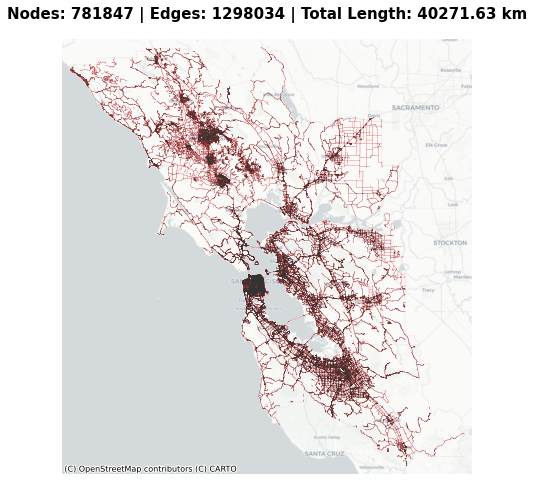

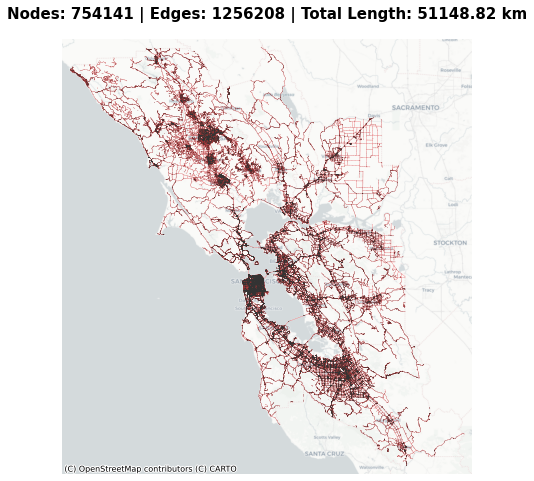

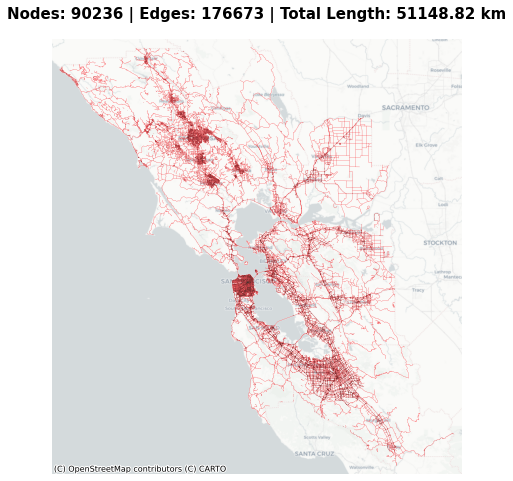

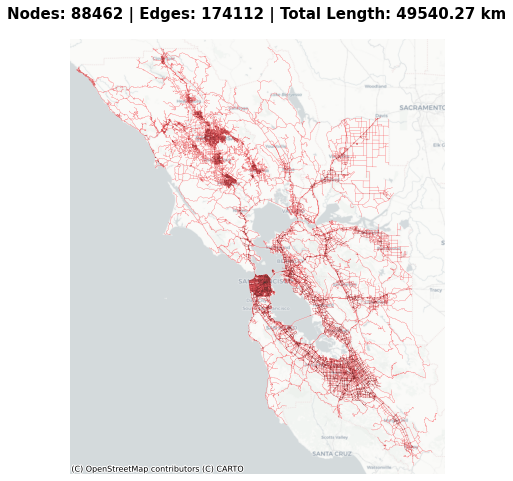

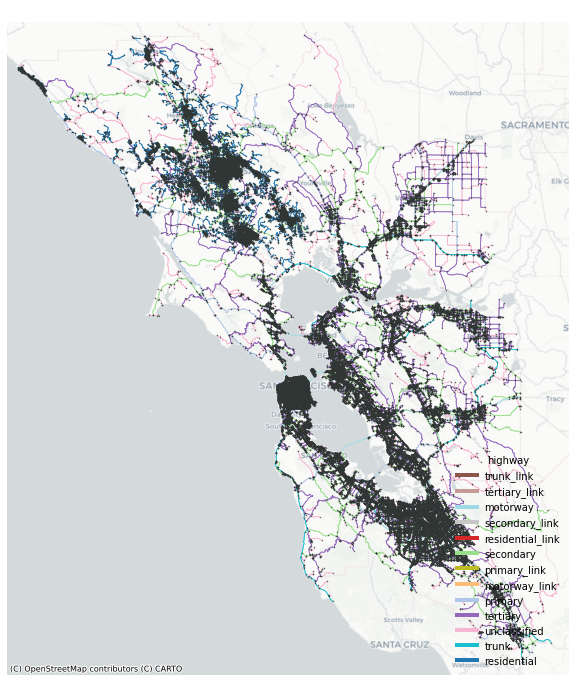

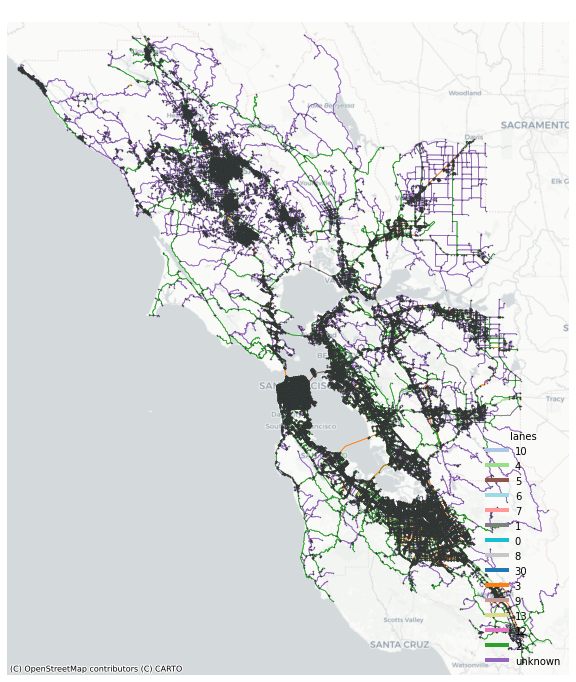

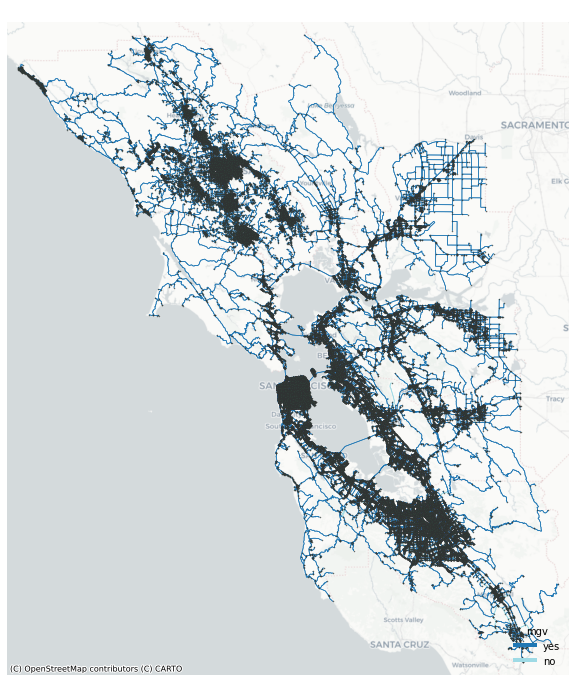

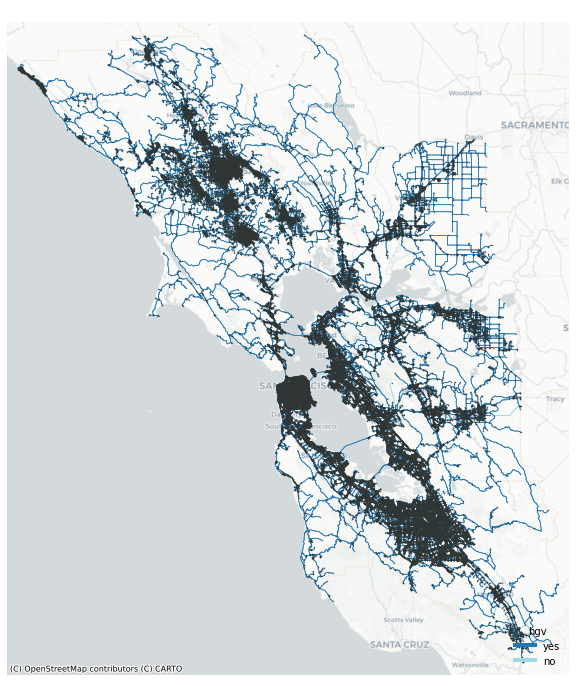

Graph successfully saved to 'sfbay_2_graph.pkl'.


In [6]:
##############################  Download Networks   ##############################
    
G = combine_graphs()

G = ox.project_graph(G, to_crs="epsg:3857")

plot(G, f'{studyArea}_{str(simpl_intersections)}_original_graph')

G_final = G.copy()

############################## Add Attributes

G_final = ox.add_edge_speeds(G_final)
# G_final = ox.add_edge_lanes(G_final)
# G_final = ox.add_edge_capacities(G_final)
nodes, edges = ox.graph_to_gdfs(G_final)
edges_freight = update_freight_script(edges)
G_final = ox.graph_from_gdfs(nodes, edges_freight, graph_attrs=G_final.graph)

nodes, edges = ox.graph_to_gdfs(G_final)
print(f'Nodes: {len(nodes)}, Edges: {len(edges)}')



############################## Consolidate Nodes

print('consolidate intersections')

G_final = ox.consolidate_intersections(G_final, tolerance=simpl_intersections, rebuild_graph=True,  dead_ends=True, reconnect_edges=True
                                      )

# Update length
nodes, edges = ox.graph_to_gdfs(G_final)
edges['length'] = edges['geometry'].length
G_final = ox.graph_from_gdfs(nodes, edges, graph_attrs=G_final.graph)


#Plot

plot(G_final, f'{studyArea}_{str(simpl_intersections)}_consolidated_graph')


############################## Simplify Network
print('simplify network')
G_final = ox.simplification.simplify_graph(G_final, 
                    edge_attrs_differ = splitLinksBy,
                    remove_rings = False,
                    track_merged = True,
                                                                 )


plot(G_final, f'{studyArea}_{str(simpl_intersections)}_simplified_graph')

############################## Truncate Network

G_final = ox.truncate.largest_component(G_final) 
plot(G_final, f'{studyArea}_{str(simpl_intersections)}_truncated_graph')

plot_graph_by_attribute(G_final, attribute='highway', title="Network Colored by Highway Type")
plot_graph_by_attribute(G_final, attribute='lanes', title="Network Colored by Number of Lanes")
plot_graph_by_attribute(G_final, attribute='mgv', title="Network Colored by Number of Lanes")
plot_graph_by_attribute(G_final, attribute='hgv', title="Network Colored by Number of Lanes")

# Define the file path where you want to save the pickle file
save_path = f'{studyArea}_{simpl_intersections}_graph.pkl'

# Save the graph using pickle
with open(save_path, 'wb') as f:
    pickle.dump(G_final, f)
print(f"Graph successfully saved to '{save_path}'.")



# Save Network for the Simulation

In [7]:
# Save GPKG

ox.save_graph_geopackage(G_final, filepath="SFBayArea.gpkg")


In [8]:
# Save OSM



G_final = ox.project_graph(G_final, to_crs="epsg:4326")
save_graph_to_osm(G_final, filename="output.osm")

In [9]:
# osmium cat sfbay-unclassified-partiallysimplified-unprojected-sfres.osm -o sfbay-unclassified-partiallysimplified-unprojected-sfres.osm.pbf
